# Δ-learning sweep 3 — postmortem

**The correction is fixing the wrong distances.**

The third campaign (`cluster_train_balanced`) was built to repair the
parallel-displaced family by more than doubling its training quota. It made
parallel-displaced *worse*. This notebook rebuilds the evidence from
`results/` and shows why: the pattern behind all three sweeps is **radial, not
motif** — every model helps 5–7 Å and damages 3–5 Å, and the 3–5 Å band holds
the deepest attractive rows.

| | |
|---|---|
| **Points clearing the gate** | **0 / 64** — same as sweeps 1 and 2. No model is deployable. |
| **Baseline to beat** | **0.2056** kcal/mol — bare `CACELLI_POTENTIAL` over the 157 attractive Cacelli rows |
| **Best of this sweep** | **0.2934** kcal/mol — `l3-n4-rc6.00`, 43% worse than doing nothing, and worse than sweep 1's 0.2196 |

Everything below is recomputed from
`results/anisoap_fit{,_motif,_balanced}/points/*/metrics.json`, the three
`dataset_config.json` files, and each sweep's best-gate model reloaded via
`fitting_anisoap.sweep.load_model`. Runtime ≈ 1 min, dominated by re-parsing
the three campaigns.

> **Requires the gitignored `results/` tree** — like the other analysis
> notebooks here, it is not runnable from a fresh clone.

> **CORRECTION (2026-09-08), read before the rest of this notebook.** Every
> number and verdict above and below was scored against **MP2**. All three
> sweeps have since been re-scored against **UMA** (`--regate`, no refits —
> see CLAUDE.md's UMA RE-SCORE note), and the headline verdict flips:
> `cluster_train` (called "S1" here) now **passes 63/64** on
> `improves_on_baseline`, best well-RMSE **0.436 → 0.346 kcal/mol**. The old
> baseline of 0.2056 kcal/mol above was GB+Q's *training* error on rows it was
> fitted to; UMA, which never saw them, scores GB+Q at 0.436, so a Δ model
> reproducing UMA *perfectly* would still have looked like it made things
> worse against the old number. That is why "0/64, same as sweeps 1 and 2" and
> "the least correction always wins ... subtracting value, not adding it"
> (Finding just below, and the `rc = 6.0` observation) are **no longer
> correct** — `rc = 6.0` won under MP2 because it was the only cutoff too
> short to see the beyond-horizon rows where UMA truncates to exactly zero and
> `Δ = -E_GBQ` becomes the (wrong) thing being fitted; under UMA the winner is
> the grid's *most* expressive corner (`l9-n6-rc12`), still climbing at every
> axis's edge.
>
> **What still holds.** The mechanism this notebook diagnoses — **radial, not
> motif** (Findings 03-04): every model improves 5-7 Å and damages 3-5 Å, and
> close-contact supply orders the three campaigns exactly as the score does —
> is independent of the reference and remains the correct explanation for why
> `cluster_train_motif`/`cluster_train_balanced` still fail 0/64 under UMA
> too. The mechanism has since been sharpened further: those two campaigns'
> failure traces to hard-core-clash pairs (`E_UMA > 0`, admitted by the old
> `min_atom_distance = 2.4`) carrying 75-76% of their Δ² fit objective, vs 41%
> for the winning `cluster_train` — see CLAUDE.md's UMA RE-SCORE and
> SIMPLIFIED notes. The motif taxonomy and the trimer path referenced
> throughout this notebook (`draw_cofacial`, `trimer_fraction`, etc.) were
> deleted in that pass; `proposals.py` now only draws uniformly.


In [1]:
import glob
import json
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from asmcmc.base.potentials import CACELLI_POTENTIAL
from asmcmc.data_preparation.cluster_analysis import load_campaign, pair_records
from asmcmc.fitting_anisoap.fit import AniSOAPDeltaPotential
from asmcmc.fitting_anisoap.sweep import load_model
from asmcmc.utils.validation import EV_TO_KCAL, _family_masks, load_cacelli_dimers

# tag -> (sweep results dir, campaign dir)
SWEEPS = {
    "S1": ("anisoap_fit", "cluster_train"),
    "S2": ("anisoap_fit_motif", "cluster_train_motif"),
    "S3": ("anisoap_fit_balanced", "cluster_train_balanced"),
}
LABEL = {
    "baseline": "Cacelli baseline",
    "S1": "S1  cluster_train",
    "S2": "S2  motif",
    "S3": "S3  balanced",
}
SERIES = ["baseline", "S1", "S2", "S3"]
# categorical slots 1-3; baseline is a reference, drawn outlined
COLOR = {"baseline": "none", "S1": "#2a78d6", "S2": "#eb6834", "S3": "#1baf7a"}
EDGE = {"baseline": "#52514e", "S1": "none", "S2": "none", "S3": "none"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

mpl.rcParams.update(
    {
        "figure.dpi": 130,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": INK2,
        "axes.labelcolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
        "text.color": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "legend.frameon": False,
    }
)


def grouped_bars(ax, groups, values, ylabel, top, label_baseline=True):
    """One group per category, one thin bar per series; baseline outlined."""
    x = np.arange(len(groups))
    bw = 0.78 / len(SERIES)
    for i, s in enumerate(SERIES):
        off = (i - (len(SERIES) - 1) / 2) * bw
        ax.bar(
            x + off,
            values[s],
            bw * 0.88,  # the gap between adjacent bars
            label=LABEL[s],
            color=COLOR[s],
            edgecolor=EDGE[s],
            linewidth=1.2,
            zorder=3,
        )
        if s == "baseline" and label_baseline:
            for xi, v in zip(x + off, values[s]):
                ax.text(xi, v + top * 0.02, f"{v:.3f}", ha="center",
                        fontsize=7.5, color=INK2, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, top)
    ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

## The three sweeps

Each sweep is the same 64-point grid over `max_angular × max_radial ×
cutoff_radius`, run against a different training campaign. `well_rmse_kcal` is
the dimer gate: RMSE against the 157 attractive Cacelli MP2 rows.

In [2]:
rows = []
for tag, (sweep, _) in SWEEPS.items():
    for path in glob.glob(f"../results/{sweep}/points/*/metrics.json"):
        m = json.load(open(path))
        rows.append(
            dict(
                tag=tag,
                key=m["key"],
                l=m["hypers"]["max_angular"],
                n=m["hypers"]["max_radial"],
                rc=m["hypers"]["cutoff_radius"],
                alpha=m["alpha"],
                train_rmse=m["train"]["rmse"],
                test_rmse=m["test"]["rmse"],
                test_skill=m["test"]["skill"],
                tr_null=m["train"]["null_rmse"],
                te_null=m["test"]["null_rmse"],
                well_rmse=m["gate"]["well_rmse_kcal"],
            )
        )
d = pd.DataFrame(rows)

# the dimer gate baseline: bare Cacelli over the attractive rows
data = load_cacelli_dimers()
att = data.energy_kcal < 0
e_base = CACELLI_POTENTIAL.pair_energy(data.uhat1, data.uhat2, data.r) * EV_TO_KCAL
BASELINE = float(np.sqrt(np.mean((e_base[att] - data.energy_kcal[att]) ** 2)))

best_keys = {t: d[d.tag == t].nsmallest(1, "well_rmse").iloc[0].key for t in SWEEPS}
quotas = {
    t: json.load(open(f"../results/{c}/dataset_config.json")).get("quotas", {})
    for t, (_, c) in SWEEPS.items()
}

print(f"baseline well RMSE = {BASELINE:.4f} kcal/mol   ({int(att.sum())} attractive rows)")

def _quota(t, motif):
    q = quotas[t].get(motif)
    return "—" if q is None else f"{q:.2f}"


summary = pd.DataFrame(
    {
        LABEL[t]: {
            "parallel-displaced quota": _quota(t, "parallel-displaced"),
            "far-slipped quota": _quota(t, "far-slipped"),
            "best well RMSE (kcal/mol)": f"{d[d.tag == t].well_rmse.min():.4f}",
            "median well RMSE (kcal/mol)": f"{d[d.tag == t].well_rmse.median():.4f}",
            "worst well RMSE (kcal/mol)": f"{d[d.tag == t].well_rmse.max():.4f}",
            "best point": "-".join(best_keys[t].split("-")[:3]),
            "points beating baseline": f"{int((d[d.tag == t].well_rmse < BASELINE).sum())}"
                                       f" / {int((d.tag == t).sum())}",
        }
        for t in SWEEPS
    }
)
summary

baseline well RMSE = 0.2056 kcal/mol   (157 attractive rows)


,S1 cluster_train,S2 motif,S3 balanced
parallel-displaced quota,—,0.08,0.18
far-slipped quota,—,0.30,0.20
best well RMSE (kcal/mol),0.2196,0.3181,0.2934
median well RMSE (kcal/mol),0.2449,0.3715,0.3234
worst well RMSE (kcal/mol),0.2859,0.5400,0.4151
best point,l5-n3-rc6.00,l7-n5-rc6.00,l3-n4-rc6.00
points beating baseline,0 / 64,0 / 64,0 / 64


### Finding 01 — two rounds of quota engineering both moved *away* from the baseline

Sweep 1 ran on `cluster_train`, whose composition nobody designed — it fell out
of the retired weighted mixture. Sweeps 2 and 3 ran on campaigns with
deliberate per-motif quotas. **The un-engineered campaign is still the best of
the three**, and it is the only one within 7% of the baseline.

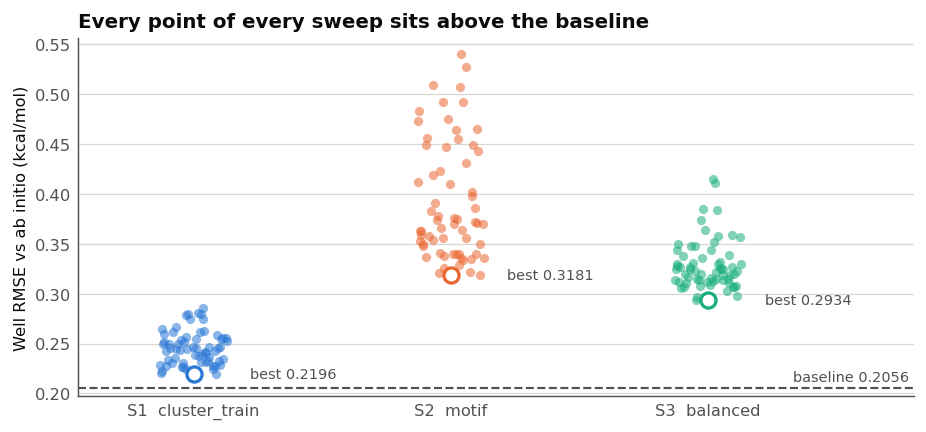

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
for i, t in enumerate(SWEEPS):
    x = d[d.tag == t]
    ax.scatter(
        np.full(len(x), i) + np.random.default_rng(0).uniform(-0.13, 0.13, len(x)),
        x.well_rmse,
        s=26, color=COLOR[t], alpha=0.55, linewidths=0, zorder=3,
    )
    ax.scatter([i], [x.well_rmse.min()], s=70, facecolor="white",
               edgecolor=COLOR[t], linewidth=1.8, zorder=4)
    ax.text(i + 0.22, x.well_rmse.min(), f"best {x.well_rmse.min():.4f}",
            va="center", fontsize=8, color=INK2)

ax.axhline(BASELINE, color=INK2, linestyle="--", linewidth=1.2, zorder=2)
ax.text(2.78, BASELINE + 0.004, f"baseline {BASELINE:.4f}",
        fontsize=8, color=INK2, va="bottom", ha="right")
ax.set_xticks(range(3))
ax.set_xticklabels([LABEL[t] for t in SWEEPS])
ax.set_xlim(-0.45, 2.8)
ax.set_ylim(0.197, None)
ax.set_ylabel("Well RMSE vs ab initio (kcal/mol)")
ax.set_title("Every point of every sweep sits above the baseline", loc="left")
ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

In all three sweeps the best-gate point sits at **`rc = 6.0 Å`, the smallest
cutoff on the grid**. The least correction always wins — which is the shape of a
model that is subtracting value, not adding it.

### Finding 02 — doubling the parallel-displaced quota made parallel-displaced worse

Sweep 2 left parallel-displaced under-bound, so `cluster_train_balanced` raised
its quota from 0.08 to 0.18 and paid for it out of far-slipped. Reload each
sweep's best-gate model and score the families directly.

In [4]:
models = {"baseline": CACELLI_POTENTIAL}
for t in SWEEPS:
    models[t] = AniSOAPDeltaPotential(
        load_model(f"../results/{SWEEPS[t][0]}/points/{best_keys[t]}")
    )

energy = {
    k: p.pair_energy(data.uhat1, data.uhat2, data.r) * EV_TO_KCAL
    for k, p in models.items()
}


def rmse(e, mask):
    return float(np.sqrt(np.mean((e[mask] - data.energy_kcal[mask]) ** 2)))


fam = _family_masks(data)
groups = {
    "cofacial": fam["cofacial"] & att,
    "parallel-displaced": fam["parallel_displaced"] & att,
    "T-shaped": fam["t_shaped"] & att,
    "unassigned": att & ~(fam["cofacial"] | fam["parallel_displaced"] | fam["t_shaped"]),
    "all attractive": att,
}

family = pd.DataFrame(
    {
        f"{name} (n = {int(m.sum())})": {LABEL[k]: rmse(e, m) for k, e in energy.items()}
        for name, m in groups.items()
    }
).T
family.round(3)

,Cacelli baseline,S1 cluster_train,S2 motif,S3 balanced
cofacial (n = 13),0.208,0.431,0.156,0.124
parallel-displaced (n = 85),0.215,0.196,0.372,0.341
T-shaped (n = 15),0.205,0.059,0.210,0.155
unassigned (n = 44),0.186,0.205,0.269,0.265
all attractive (n = 157),0.206,0.220,0.318,0.293


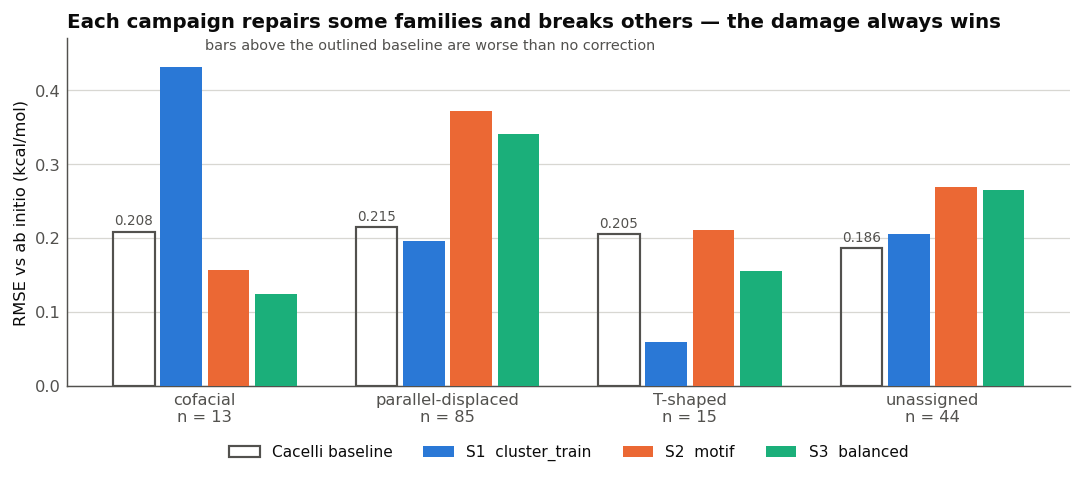

In [5]:
fams = ["cofacial", "parallel-displaced", "T-shaped", "unassigned"]
fig, ax = plt.subplots(figsize=(8.4, 3.8))
grouped_bars(
    ax,
    [f"{f}\nn = {int(groups[f].sum())}" for f in fams],
    {s: [rmse(energy[s], groups[f]) for f in fams] for s in SERIES},
    "RMSE vs ab initio (kcal/mol)",
    top=0.47,
)
ax.set_title(
    "Each campaign repairs some families and breaks others — the damage always wins",
    loc="left",
)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=8.5)
ax.text(0, 0.455, "bars above the outlined baseline are worse than no correction",
        fontsize=8, color=INK2, ha="left")
plt.tight_layout()
plt.show()

Sweep 1 fixed T-shaped and broke cofacial; sweeps 2 and 3 fixed cofacial and
broke **parallel-displaced — which carries 85 of the 157 attractive rows**. Its
error is now 0.341 against the baseline's 0.215: the correction is worse than
applying none, on the very family it was built to repair.

### Finding 03 — split the same residuals by distance and the motif story disappears

This is the diagnosis. Bin the *identical* residuals by centre–centre
separation instead of by motif.

In [6]:
R_BANDS = [(3, 5), (5, 7), (7, 9), (9, 30)]
r_norm = np.linalg.norm(data.r, axis=1)
band_masks = {
    ("3–5 Å" if hi == 5 else "5–7 Å" if hi == 7 else "7–9 Å" if hi == 9 else "≥ 9 Å"):
        att & (r_norm >= lo) & (r_norm < hi)
    for lo, hi in R_BANDS
}

bands = pd.DataFrame(
    {
        f"{name} (n = {int(m.sum())}, mean E {data.energy_kcal[m].mean():+.2f})": {
            LABEL[k]: rmse(e, m) for k, e in energy.items()
        }
        for name, m in band_masks.items()
    }
).T
bands.round(3)

,Cacelli baseline,S1 cluster_train,S2 motif,S3 balanced
"3–5 Å (n = 52, mean E -1.77)",0.187,0.323,0.493,0.448
"5–7 Å (n = 42, mean E -1.10)",0.326,0.206,0.264,0.254
"7–9 Å (n = 31, mean E -0.28)",0.104,0.104,0.104,0.104
"≥ 9 Å (n = 32, mean E -0.02)",0.015,0.015,0.015,0.015


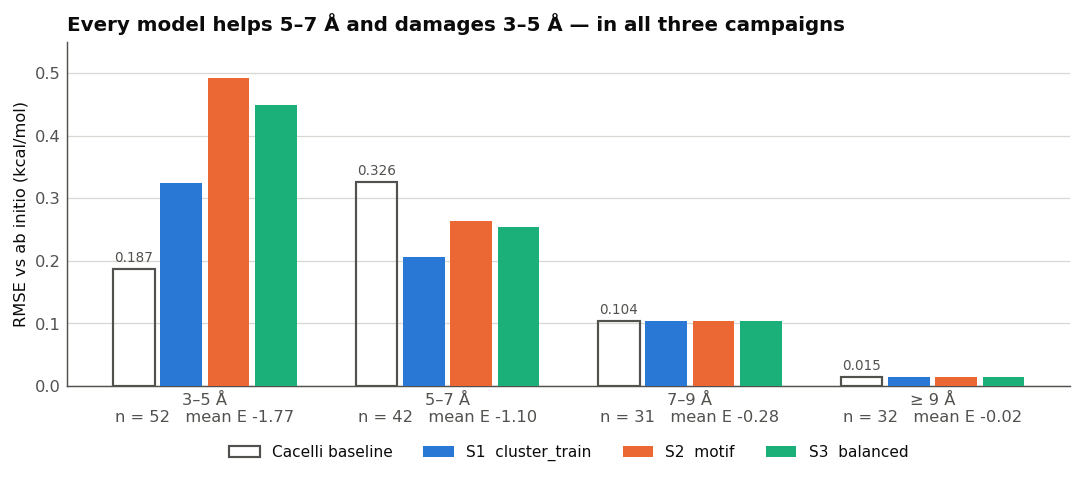

In [7]:
names = list(band_masks)
fig, ax = plt.subplots(figsize=(8.4, 3.8))
grouped_bars(
    ax,
    [f"{n}\nn = {int(band_masks[n].sum())}   mean E {data.energy_kcal[band_masks[n]].mean():+.2f}"
     for n in names],
    {s: [rmse(energy[s], band_masks[n]) for n in names] for s in SERIES},
    "RMSE vs ab initio (kcal/mol)",
    top=0.55,
)
ax.set_title("Every model helps 5–7 Å and damages 3–5 Å — in all three campaigns", loc="left")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=8.5)
plt.tight_layout()
plt.show()

Every correction, in every campaign, does the same two things: it **improves
5–7 Å and damages 3–5 Å**. The 3–5 Å band holds the 52 deepest attractive rows
(mean −1.77 kcal/mol), so the damage dominates the aggregate and no model
clears the gate. Beyond 7 Å all four series are *identical* — the correction
truncates to exactly zero there, so the far field contributes nothing either
way.

That reframes the problem. **The families were never the axis; they were a
proxy for how close together the two molecules sit.**

### Finding 04 — close-contact training supply tracks the gate across all three campaigns

The quota restructure roughly halved the number of training pairs inside 5 Å.
Reload the campaigns and count. *(This is the slow cell — ~35 s.)*

In [8]:
supply = {}
for t, (_, campaign) in SWEEPS.items():
    frames, cfg = load_campaign(f"../results/{campaign}")
    rec = pair_records(frames)
    r, delta = rec["r"], rec["delta"] * EV_TO_KCAL
    near = (r >= 3.0) & (r < 4.0)
    supply[LABEL[t]] = {
        "total pairs": len(r),
        "pairs below 5 Å": int((r < 5).sum()),
        "share below 5 Å (%)": 100 * float((r < 5).mean()),
        "pairs below 4 Å": int((r < 4).sum()),
        "rms |Δ| at 3–4 Å (kcal/mol)": float(np.sqrt(np.mean(delta[near] ** 2))),
        "median |Δ|, all pairs (kcal/mol)": float(np.median(np.abs(delta))),
        "benchmark RMSE at 3–5 Å": rmse(energy[t], band_masks["3–5 Å"]),
        "best well RMSE (kcal/mol)": float(d[d.tag == t].well_rmse.min()),
    }
pd.DataFrame(supply).round(3)

,S1 cluster_train,S2 motif,S3 balanced
total pairs,11900.000,12096.000,12094.000
pairs below 5 Å,1871.000,938.000,1153.000
share below 5 Å (%),15.723,7.755,9.534
pairs below 4 Å,302.000,125.000,183.000
rms |Δ| at 3–4 Å (kcal/mol),1.035,1.856,2.069
"median |Δ|, all pairs (kcal/mol)",0.036,0.016,0.017
benchmark RMSE at 3–5 Å,0.323,0.493,0.448
best well RMSE (kcal/mol),0.220,0.318,0.293


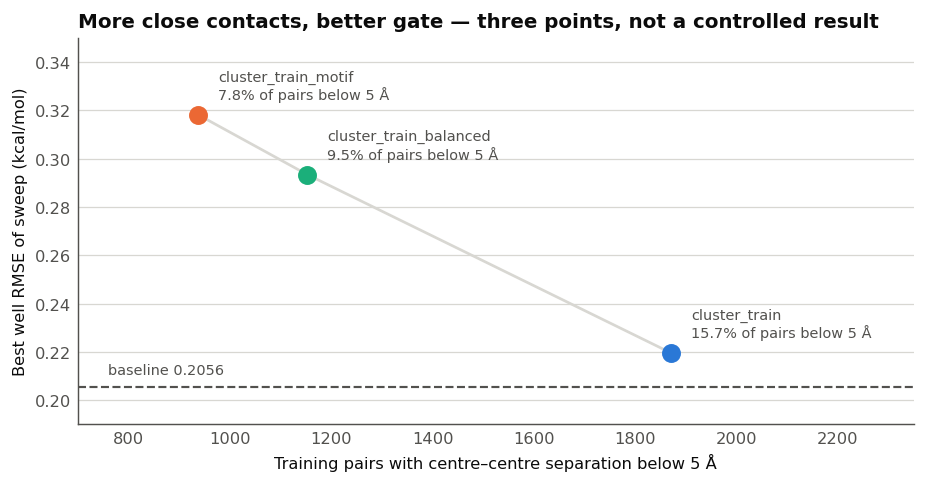

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
xs = [supply[LABEL[t]]["pairs below 5 Å"] for t in SWEEPS]
ys = [supply[LABEL[t]]["best well RMSE (kcal/mol)"] for t in SWEEPS]
order = np.argsort(xs)
ax.plot(np.array(xs)[order], np.array(ys)[order], color=GRID, linewidth=1.5, zorder=2)
for t, x, y in zip(SWEEPS, xs, ys):
    ax.scatter([x], [y], s=110, color=COLOR[t], linewidths=0, zorder=4)
    ax.annotate(
        f"{SWEEPS[t][1]}\n{supply[LABEL[t]]['share below 5 Å (%)']:.1f}% of pairs below 5 Å",
        (x, y), textcoords="offset points", xytext=(11, 7),
        fontsize=8, color=INK2, va="bottom",
    )
ax.axhline(BASELINE, color=INK2, linestyle="--", linewidth=1.2, zorder=3)
ax.text(760, BASELINE + 0.004, f"baseline {BASELINE:.4f}", fontsize=8,
        color=INK2, va="bottom")
ax.set_xlim(700, 2350)
ax.set_ylim(0.19, 0.35)
ax.set_xlabel("Training pairs with centre–centre separation below 5 Å")
ax.set_ylabel("Best well RMSE of sweep (kcal/mol)")
ax.set_title("More close contacts, better gate — three points, not a controlled result", loc="left")
ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

Ordering the three campaigns by close-contact supply reproduces their ordering
on the benchmark exactly. The mechanism is in
[proposals.py](../asmcmc/data_preparation/proposals.py): only `draw_cofacial`
and `draw_parallel_displaced` sample down to 3.4 Å. `draw_far_slipped` floors
at 4.0 Å, `draw_t_shaped` at 4.2 Å, and `draw_uniform` is volume-uniform over
[3.4, 15] — which puts only 2.6% of its mass below 5 Å. Then the
per-configuration → per-pair dilution (×0.42 at `trimer_fraction = 0.7`) cuts
it again.

The 3–4 Å band carries rms |Δ| of **2.07 kcal/mol** against a campaign-wide
median of **0.017** — two orders of magnitude — on **1.51%** of pairs. *The
correction has the most to learn exactly where it has almost nothing to learn
from.*

> **Not yet tested.** This is a three-point correlation with a plausible
> mechanism, not a controlled result.

### Finding 05 — the grid is exhausted, and the fit metrics are not comparable

Two things to stop trusting.

In [10]:
diag = pd.DataFrame(
    {
        LABEL[t]: {
            "test RMSE, min (kcal/mol)": d[d.tag == t].test_rmse.min(),
            "test RMSE, max (kcal/mol)": d[d.tag == t].test_rmse.max(),
            "test RMSE spread (%)": 100 * (d[d.tag == t].test_rmse.max()
                                           / d[d.tag == t].test_rmse.min() - 1),
            "median train RMSE (kcal/mol)": d[d.tag == t].train_rmse.median(),
            "median test RMSE (kcal/mol)": d[d.tag == t].test_rmse.median(),
            "median test skill": d[d.tag == t].test_skill.median(),
            "test/train null_rmse ratio": (d[d.tag == t].te_null.mean()
                                           / d[d.tag == t].tr_null.mean()),
            "RidgeCV log10(alpha), min": np.log10(d[d.tag == t].alpha.min()),
            "RidgeCV log10(alpha), max": np.log10(d[d.tag == t].alpha.max()),
            "RidgeCV alpha, decades spanned": np.log10(
                d[d.tag == t].alpha.max() / d[d.tag == t].alpha.min()),
            "corr(test skill, well RMSE)": d[d.tag == t].test_skill.corr(
                d[d.tag == t].well_rmse),
        }
        for t in SWEEPS
    }
)
diag.round(4)

,S1 cluster_train,S2 motif,S3 balanced
"test RMSE, min (kcal/mol)",0.3939,0.3104,0.3504
"test RMSE, max (kcal/mol)",0.4317,0.3476,0.3774
test RMSE spread (%),9.5987,12.0010,7.7316
median train RMSE (kcal/mol),0.4055,0.3280,0.3280
median test RMSE (kcal/mol),0.4140,0.3255,0.3609
median test skill,0.1928,0.5623,0.5292
test/train null_rmse ratio,0.8983,1.0417,1.1087
"RidgeCV log10(alpha), min",-4.0000,-8.5000,-10.0000
"RidgeCV log10(alpha), max",-1.0000,0.5000,-0.5000
"RidgeCV alpha, decades spanned",3.0000,9.0000,9.5000


**The grid has stopped resolving anything.** In sweep 3 test RMSE spans
0.350–0.377 across all 64 points — about 7%. `max_angular` saturates by l = 5
where sweep 1 was still climbing at l = 9, and `cutoff_radius` is non-monotonic
(6.0 and 12.0 both beat 9.0). RidgeCV's chosen α wanders over **9.5 decades**
(1e-10 to 0.32) and correlates with the gate rather than with fit quality — note
`corr(test skill, well RMSE)` is *negative* in sweeps 2 and 3, so on those
campaigns a better Δ fit buys a worse potential. **The campaign is the
binding constraint now, not the representation** — a fourth sweep over the same
grid would tell us nothing.

**Cross-campaign fit metrics are contaminated by the split.** The test/train
`null_rmse` ratio moves from 0.898 to 1.042 to 1.109 across the three
campaigns: the single `split_seed = 0` drew held-out sets of materially
different intrinsic difficulty. Median *train* RMSE is 0.328 for both sweeps 2
and 3, while their *test* RMSE differs 0.326 vs 0.361 — identical fit quality,
and the gap is split luck.

> **Correction to the project notes.** `CLAUDE.md` currently says to compare
> absolute `rmse` in kcal/mol because `test_skill` is normalised per campaign.
> **Absolute RMSE is not safe either.** The only clean cross-campaign number is
> the dimer gate, which scores a fixed 197 rows with no split and no
> composition dependence.

## What the next campaign has to change

1. **Put real sampling mass inside 4.5 Å.** No quota in the current generator
   supplies it densely — the two motifs that reach 3.4 Å are diluted ×0.42 by
   the trimer fraction, and the uniform draw contributes 2.6%. This needs a
   **radial** change, not another quota reshuffle.
2. **Reclaim the far field.** Roughly half of every campaign's pairs sit beyond
   9 Å carrying |Δ| ≈ 0.03 kcal/mol, and the model truncates to zero there
   anyway. That budget buys close contacts instead.
3. **Record per-family and per-r-band gate residuals in the sweep artifacts.**
   Both decompositions above had to be computed by reloading every model and
   rescoring it. Without them in `metrics.json`, diagnosing a fourth campaign
   costs the same manual pass.
4. **Score on repeated splits, not one.** A single `split_seed` is why sweeps 2
   and 3 look 11% apart on a metric where their fits are identical.

**The cheap test to run first** — before committing a fourth 5000-configuration
campaign: refit the existing `cluster_train_balanced` descriptors with sample
weights concentrated on close-contact frames, plus a far-weighted control arm
that should move the gate the *other* way. Costs minutes and no new UMA
labelling.

---

*Comparability across sweeps was checked directly: re-running sweep 2's
`l5-n5-rc7.50` under today's `fitting_anisoap/data.py` reproduces its stored
test RMSE to nine decimal places, so the descriptor and fit paths have not
moved between campaigns.*